In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [18]:
df= pd.read_parquet('../data/processed/tablon_analitico.parquet')
df_diario= pd.read_parquet('../data/processed/tablon_analitico_diario.parquet')

## Análisis de Irradiacion y Temperatura en plantas 1 y 2
- Los análisis van a realizarse de forma ordenada según el propio ciclo de generación de energía solar fotovoltaica: captación > Potencia DC > Potencia AC y Energia total generada.

In [192]:
#df reducido para evitar evitar trabajar con datos duplicados (Irradiacion y temperatura no dependen de Inversores): filtramos en 2 inversores
df_reducido = df.loc[(df['id_inversor'] == '1BY6WEcLGh8j5v7') | (df['id_inversor'] == 'xMbIugepa2P7lBB'), 'id_planta':'energia_diaria_kwh']
#Construir variable fecha a partir del indice
df_reducido['fecha'] = pd.to_datetime(df_reducido.index).date

In [ ]:
#Datasets temporales para heatmaps de irradiacion y temperatura por horas planta 1 y 2

irradiacion_hora_planta = df_reducido.pivot_table(
    index='hora',
    columns='id_planta',
    values='irradiacion_wh_m2',
    aggfunc='sum'
)
temp_hora_planta = df_reducido.pivot_table(
    index='hora',
    columns='id_planta',
    values='temperatura_modulo_c',
    aggfunc='mean'
)

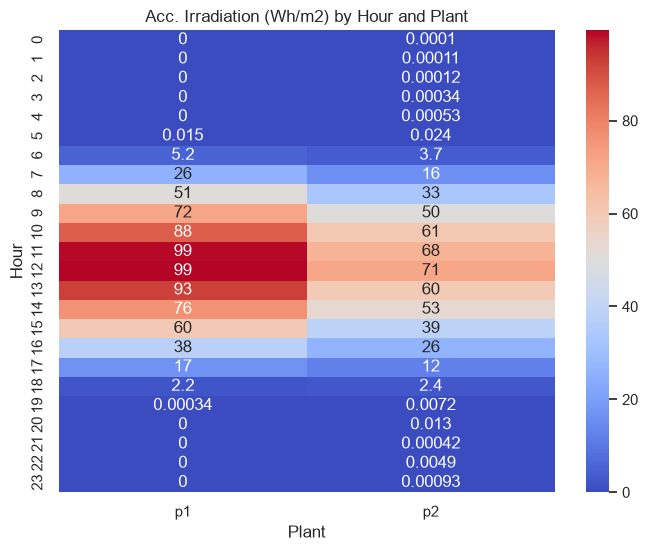

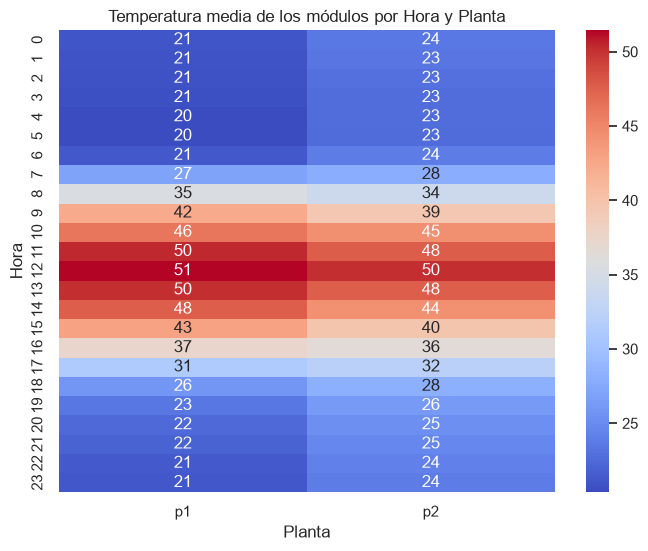

In [ ]:
#Heatmap de Irradiacion acumulada en plantas 1 y 2 por hora
plt.figure(figsize=(8, 6))
sns.heatmap(irradiacion_hora_planta, annot=True, cmap="coolwarm")
plt.title("Acc. Irradiation (Wh/m2) by Hour and Plant")
plt.xlabel("Plant")
plt.ylabel("Hour")
plt.show()

#Heatmap de temperatura media por hora y planta
plt.figure(figsize=(8,6))
sns.heatmap(temp_hora_planta, annot=True, cmap="coolwarm")
plt.title("Temperatura media de los módulos por Hora y Planta")
plt.xlabel("Planta")
plt.ylabel("Hora")
plt.show()

- **Existen diferencias notables en la irradiación acumulada entre ambas plantas**. Se seguirá tirando del hilo para evaular posibles fallos en generación y/o sensores. Por ahora **no se detectan anomalías** en valores de temperatura media para ambas plantas. A continuación se realizará un **analisis por fecha, hora y planta para detectar posibles gaps y anomalías de medición.**

In [29]:
#datasets temporales para generar los heatmaps

irradiacion_temp_p1 = df_reducido[df_reducido['id_planta'] == 'p1'].pivot_table(
    index='fecha',
    columns='hora',
    values='irradiacion_wh_m2',
    aggfunc='mean'
)

irradiacion_temp_p2 = df_reducido[df_reducido['id_planta'] == 'p2'].pivot_table(
    index='fecha',
    columns='hora',
    values='irradiacion_wh_m2',
    aggfunc='mean'
)

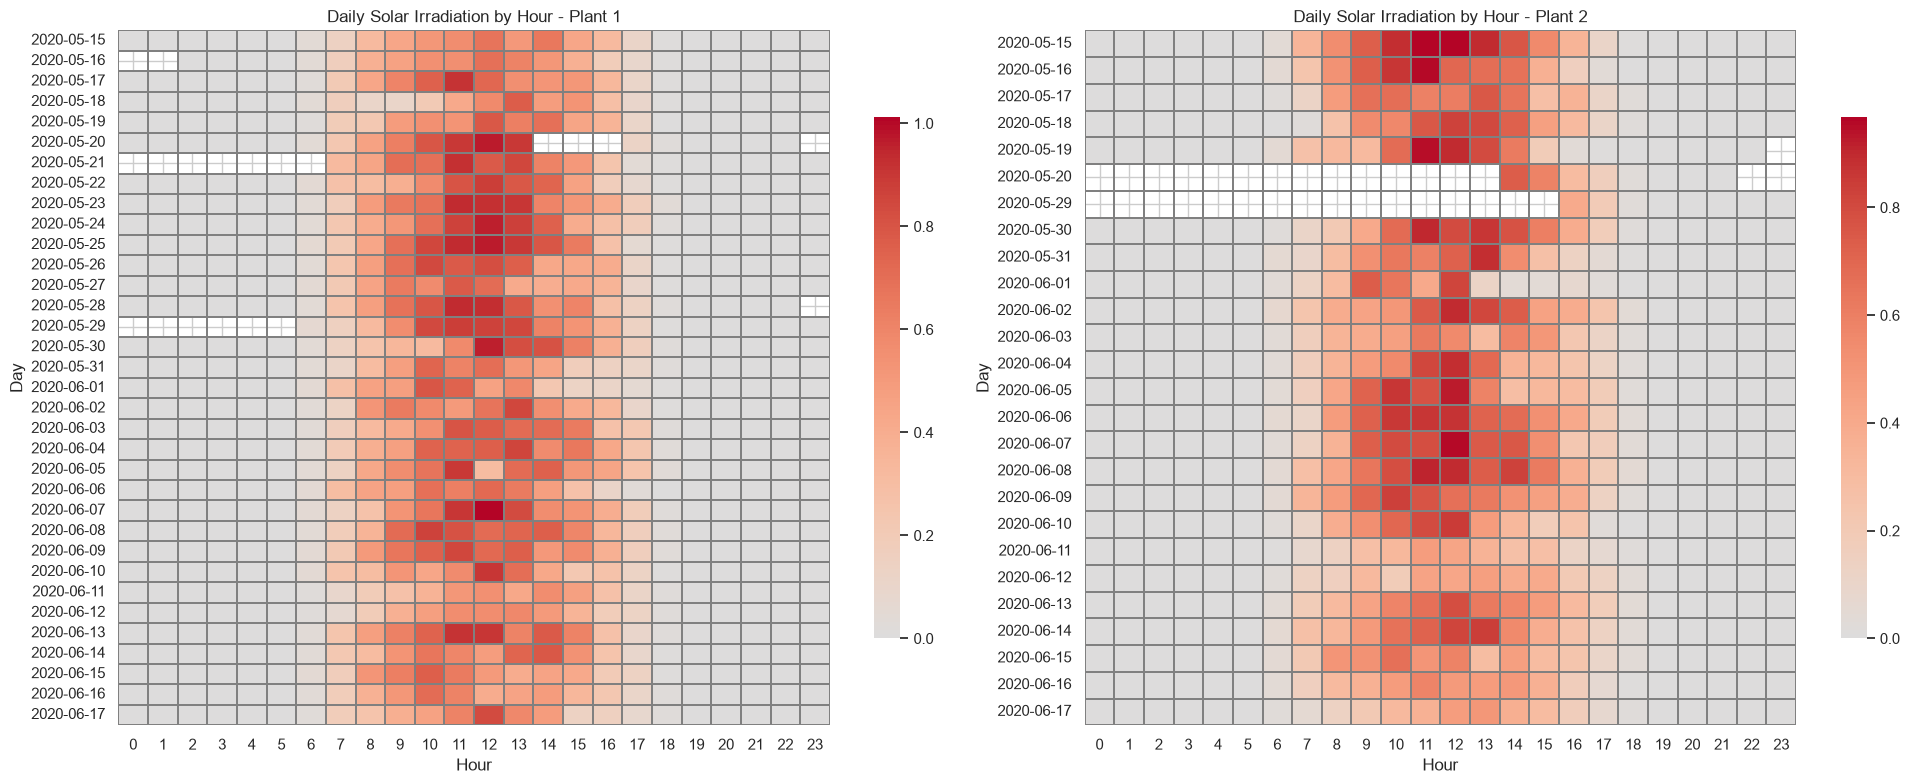

In [144]:
#Heatmaps de irradiacion diaria por horas plantas 1 y 2

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=False)

heatmaps = {
    "Plant 1": irradiacion_temp_p1,
    "Plant 2": irradiacion_temp_p2,
}

for ax, (title, data) in zip(axes, heatmaps.items()):
    sns.heatmap(
        data,
        ax=ax,
        cmap="coolwarm",
        center=0,
        annot=False,
        linewidths=0.2,
        linecolor="gray",
        cbar_kws={"shrink": 0.75},
        yticklabels=True
    )

    ax.set_title(f"Daily Solar Irradiation by Hour - {title}", fontsize=12)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Day")

plt.tight_layout()
plt.show()

#### Insight 4: Analisis de irradiacion solar en plantas 1 y 2

**Se ha identificado falta de datos de captacion y datos anómalos en ambas plantas:**
- Planta 1: falta de datos parciales los días 2020-05-16, 2020-05-20, 2020-05-21, 2020-05-28 y 2020-05-29.
- Planta 2: falta de datos parciales los días 2020-05-29, 2020-05-20 y 2020-05-29. Falta de datos completos: del 2020-05-21 al 2020-05-28.
- La ausencia de datos es aun incierta pero todo apunta a fallos en los sensores de irradiación, ya que si que se genera potencia DC.

## Irradiacion vs Energia generada 
- Se va a analizar la irradiación (suma) respecto a la energia total generada (max.) a nivel diario para detectar posibles fallos de medición de los sensores de irradiación.

In [405]:
#Crear Variable de energia total generada cada 15 minutos
df = df.sort_values(["id_planta", "id_inversor", "fecha"]).sort_index().copy()

df["energia_15min_kwh"] = (
    df.groupby(["id_planta", "id_inversor", "fecha"])["energia_diaria_kwh"]
    .diff()
)

df["energia_15min_kwh"] = df["energia_15min_kwh"].clip(lower=0)

In [406]:
#Calcular Ratio Energia/Irradiacion para intervalos de 15 minutos
df["ratio_energia_irradiacion_15min"] = np.where(
    df["irradiacion_wh_m2"] > 0,
    df["energia_15min_kwh"] / df["irradiacion_wh_m2"],
    np.nan
)

In [407]:
# Calcular Mediana del Ratio Energia/Irradiacion para intervalos de 15 minutos
ratio_mediana_15min = (
    df.loc[
        (df["energia_15min_kwh"] > 0) & (df["irradiacion_wh_m2"] > 0),
    ]
    .groupby("id_planta")["ratio_energia_irradiacion_15min"]
    .agg(
        median="median",
        p10=lambda s: s.quantile(0.10),
        p90=lambda s: s.quantile(0.90)
    )
)

In [409]:
# Datasets y variables a nivel diario para generar barplot
df_diario_irradiacion_energia = (
    df.groupby(["fecha", "id_planta"], as_index=False)
    .agg(
        irradiacion=("irradiacion_wh_m2", "sum"),
        energia=("energia_15min_kwh", "sum")
    )
)
df_diario_irradiacion_energia["ratio"] = \
    df_diario_irradiacion_energia["energia"] / df_diario_irradiacion_energia["irradiacion"]

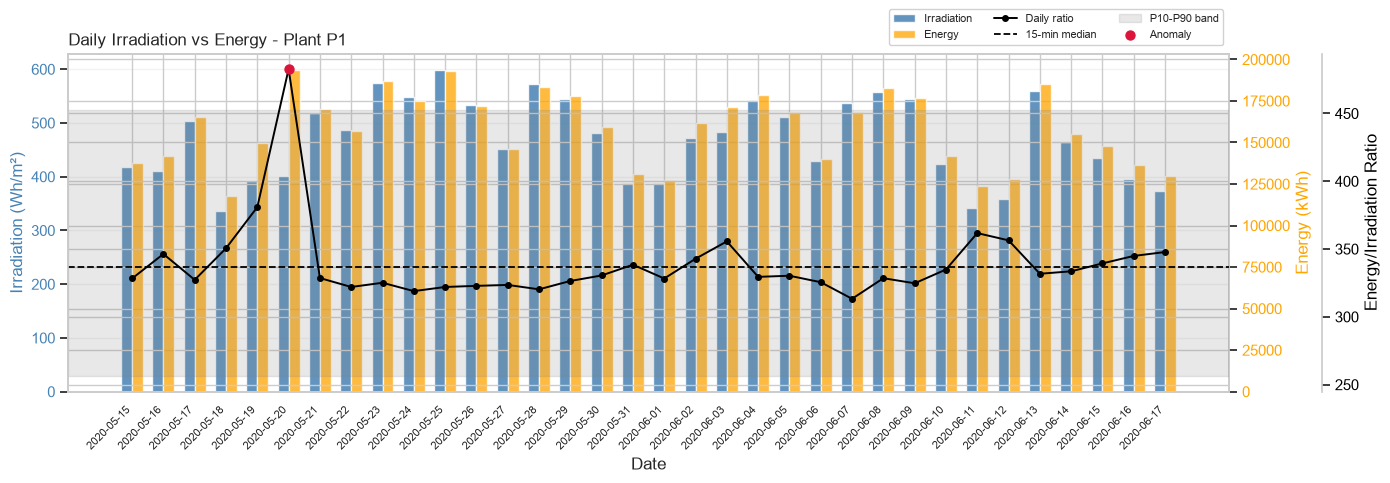

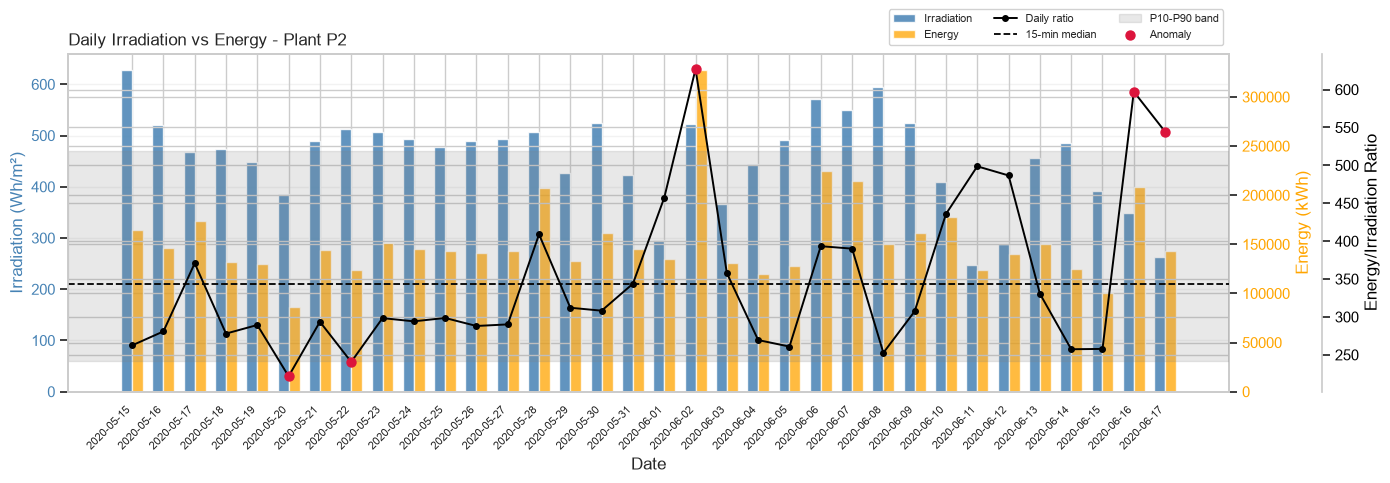

In [ ]:
#Barplot Energia vs Irradiacion por planta con Ratio
for planta, d in df_diario_irradiacion_energia.groupby("id_planta"):
    d = d.sort_values("fecha").reset_index(drop=True)
    stats = ratio_mediana_15min.loc[planta]

    x = np.arange(len(d))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("axes", 1.08))

    b1 = ax1.bar(x - width / 2, d["irradiacion"], width, color="steelblue", alpha=0.85)
    b2 = ax2.bar(x + width / 2, d["energia"], width, color="orange", alpha=0.75)

    band = ax3.axhspan(stats["p10"], stats["p90"], color="gray", alpha=0.18)
    base = ax3.axhline(stats["median"], color="black", linestyle="--", linewidth=1.3)
    line, = ax3.plot(x, d["ratio"], "o-", color="black", linewidth=1.4, markersize=4)

    out = d[~d["ratio"].between(stats["p10"], stats["p90"])]
    points = ax3.scatter(out.index, out["ratio"], color="crimson", s=42, zorder=5)

    ax1.set_title(f"Daily Irradiation vs Energy - Plant {planta.upper()}", loc="left")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Irradiation (Wh/m²)", color="steelblue")
    ax2.set_ylabel("Energy (kWh)", color="orange")
    ax3.set_ylabel("Energy/Irradiation Ratio", color="black")

    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax2.tick_params(axis="y", labelcolor="orange")
    ax3.tick_params(axis="y", labelcolor="black")

    ax1.set_xticks(x)
    ax1.set_xticklabels(pd.to_datetime(d["fecha"]).dt.strftime("%Y-%m-%d"), rotation=45, ha="right", fontsize=8)

    ax1.legend(
        [b1, b2, line, base, band, points],
        ["Irradiation", "Energy", "Daily ratio", "15-min median", "P10-P90 band", "Anomaly"],
        loc="lower right",
        bbox_to_anchor=(1, 1.01),
        ncol=3,
        fontsize=8,
        framealpha=0.9
    )

    ax1.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

### Analisis profundo de fallos en sensores de Irradiación por dia y planta

In [412]:
df_diario_irradiacion_energia = df_diario_irradiacion_energia.merge(ratio_mediana_15min, on="id_planta", how="left")
df_diario_irradiacion_energia['anomaly_score'] = (
    df_diario_irradiacion_energia['median'] - df_diario_irradiacion_energia['ratio']).abs()

In [414]:
#Normalizamos el score
df_diario_irradiacion_energia["anomaly_score"] = (
    df_diario_irradiacion_energia
    .groupby("id_planta")["anomaly_score"]
    .transform(lambda s: 10 * (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else 0)
)

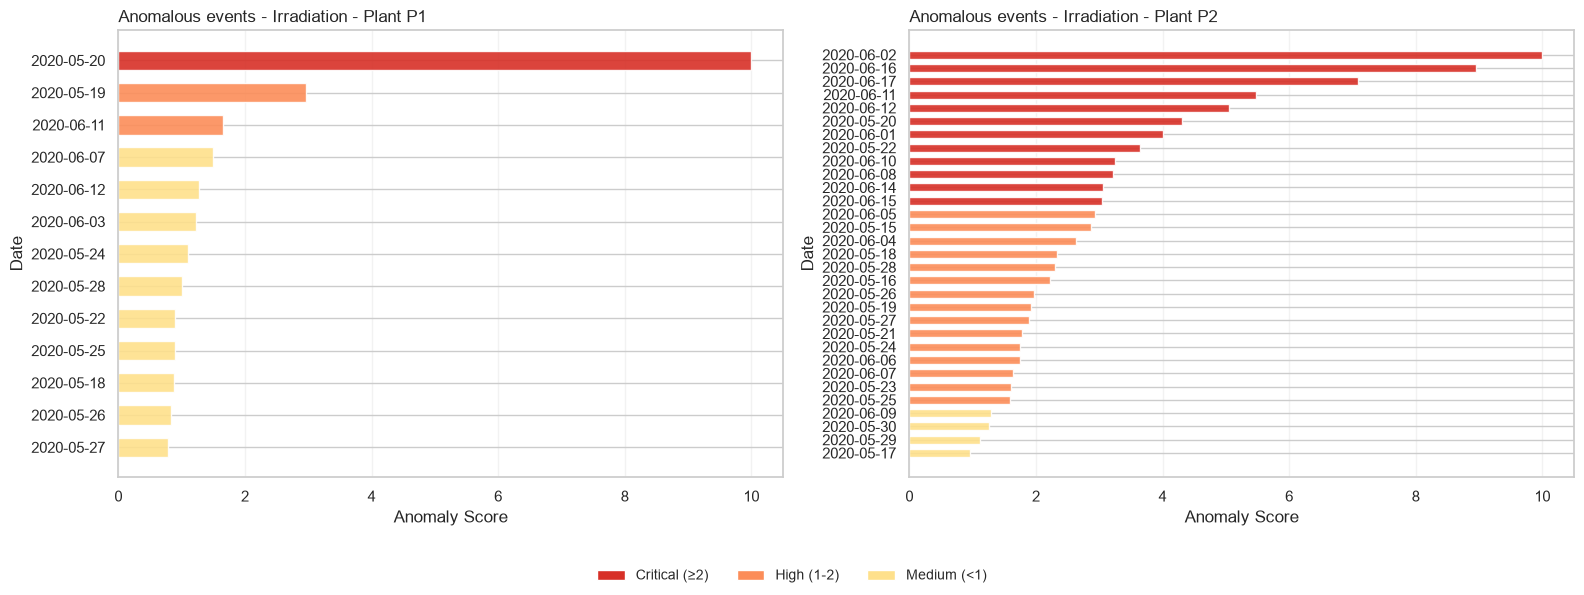

In [416]:
from matplotlib.patches import Patch

plantas = ["p1", "p2"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

for ax, planta in zip(axes, plantas):
    d = (
        df_diario_irradiacion_energia[
            (df_diario_irradiacion_energia["id_planta"].str.lower() == planta) &
            (df_diario_irradiacion_energia["anomaly_score"] > 0.75)
        ]
        .sort_values("anomaly_score", ascending=True)
        .copy()
    )

    d["color"] = d["anomaly_score"].apply(
        lambda s: "#d73027" if s >= 3 else "#fc8d59" if s >= 1.5 else "#fee08b"
    )

    ax.barh(
        d["fecha"].dt.strftime("%Y-%m-%d"),
        d["anomaly_score"],
        color=d["color"],
        alpha=0.9,
        height=0.6,
    )

    ax.set_title(f"Anomalous events - Irradiation - Plant {planta.upper()}", loc="left")
    ax.set_xlabel("Anomaly Score")
    ax.set_ylabel("Date")
    ax.grid(axis="x", alpha=0.25)

legend_elements = [
    Patch(facecolor="#d73027", label="Critical (≥2)"),
    Patch(facecolor="#fc8d59", label="High (1-2)"),
    Patch(facecolor="#fee08b", label="Medium (<1)")
]

fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=10, frameon=False)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

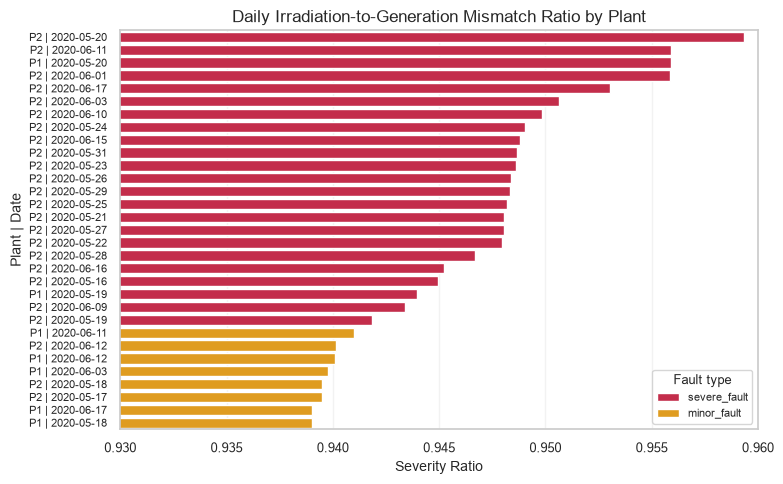

In [ ]:
#Ranking barplot de anomalias de Irradiacion vs Energia Generada por planta y fecha

#df de anomalias filtrado
df_anomalias_energia_potencia = (
    df_score_energia_potencia[df_score_energia_potencia["clasificacion"] != "normal"]
    .copy()
)
#Variables para el barplot
df_anomalias_energia_potencia["fecha_str"] = pd.to_datetime(df_anomalias_energia_potencia["fecha"]).dt.strftime("%Y-%m-%d")
df_anomalias_energia_potencia["label"] = (
    df_anomalias_energia_potencia["id_planta"].str.upper()
    + " | "
    + df_anomalias_energia_potencia["fecha_str"]
)

# Fallos más graves arriba
df_anomalias_energia_potencia = df_anomalias_energia_potencia.sort_values("puntuacion_norm", ascending=False)

#Barplot
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_ratio_anom,
    y="label",
    x="ratio",
    hue="clasificacion",
    palette={
        "minor_fault": "orange",
        "severe_fault": "crimson"
    },
    dodge=False
)

# Labels más pequeños para evitar solapes
ax.tick_params(axis="y", labelsize=8)
ax.tick_params(axis="x", labelsize=9)

ax.set_title("Daily Irradiation-to-Generation Mismatch Ratio by Plant", fontsize=12)
ax.set_xlabel("Severity Ratio", fontsize=10)
ax.set_ylabel("Plant | Date", fontsize=10)

# Eje X fijo de 0.92 a 1
ax.set_xlim(0.93, 0.96)

ax.legend(
    title="Fault type",
    fontsize=8,
    title_fontsize=9,
    loc="lower right"
)

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

#### Insight 5: Existen fallos en los sensores de medición de irradiación solar

Debido a que existen tramos sin registro de irradiación pero si existe energia generada, los fallos provienen de los equipos de medición de irradiación.

1. Planta 1: Existen ciertas anomalías entre irradiación y energia generada en los días 19 y 20 de Mayo.
2. Planta 2: Se observan numerosas anomalías de medición de irradiación en diversos días. Los mas destacables son: 19, 20 y 22 Mayo, 1 a 3 de Junio, 9 a 12 de Junio, 16 y 17 de Junio.

## Irradiacion VS potencia DC
- Se va a hacer un análisis de Irradiación VS Potencia DC para detectar posibles anomalías y descorrelaciones.

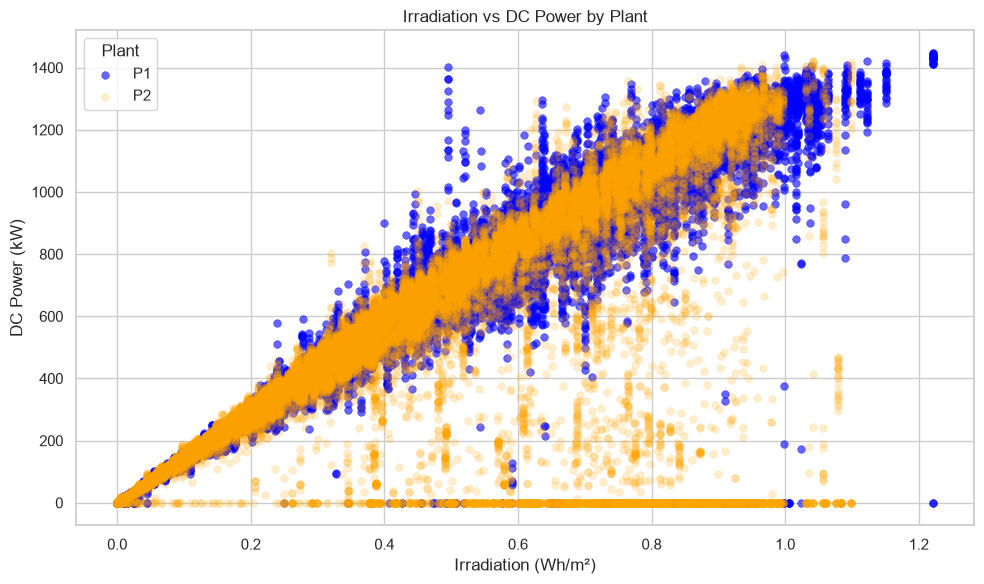

In [ ]:
# Scatter superpuesto entre irradiacion y potencia DC por planta

plt.figure(figsize=(10, 6))

colors = {
    "p1": "blue",
    "p2": "orange",
}

alphas = {
    "p1": 0.6,
    "p2": 0.2,
}

for plant in ["p1", "p2"]:
    data_plant = (
        df[df["id_planta"] == plant]
        .reset_index(drop=True)
    )

    sns.scatterplot(
        data=data_plant,
        x="irradiacion_wh_m2",
        y="potencia_dc_kw",
        color=colors[plant],
        alpha=alphas[plant],
        label=plant.upper(),
        s=30,
        edgecolor=None
    )

plt.legend(title="Plant")
plt.xlabel("Irradiation (Wh/m²)")
plt.ylabel("DC Power (kW)")
plt.title("Irradiation vs DC Power by Plant")
plt.tight_layout()
plt.show()

- En la planta 2 se observa una **descorrelacion destacable entre Irradiación y Potencia**. Se analizará la **correlación entre Potencia DC y AC** para comprovar si existe problema en la **transformación de potencia** en puntos anómalos.

In [ ]:
#Pearson y Spearman entre potencia DC y potencia AC en planta 2 solo en puntos anómalos
irradiacion_umbral = 0.2
potencia_umbral = 50

df_anomalos = df[(df['irradiacion_wh_m2'] >= irradiacion_umbral) &
                 (df['potencia_dc_kw'] <= potencia_umbral)
].copy()

df_corr = df_anomalos[["potencia_dc_kw","potencia_ac_kw"]].dropna()

pearson_corr = df_corr["potencia_dc_kw"].corr(
    df_corr["potencia_ac_kw"],
    method="pearson"
)

spearman_corr = df_corr["potencia_dc_kw"].corr(
    df_corr["potencia_ac_kw"],
    method="spearman"
)

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Pearson strength 0-1: {abs(pearson_corr):.3f}")

print(f"Spearman correlation: {spearman_corr:.3f}")
print(f"Spearman strength 0-1: {abs(spearman_corr):.3f}")

Pearson correlation: 1.000
Pearson strength 0-1: 1.000
Spearman correlation: 1.000
Spearman strength 0-1: 1.000


#### Insight 6: Descorrelación clara entre Irradiación y Potencia DC. Fallos de transformación de potencia DC/AC descartados.
- Se han identificado multitud de **descorrelaciones entre Irradiación y Potencia DC principalmente en la Planta 2** aunque **existe correlación entre Potencia DC y AC en valores anómalos**, lo cual **descarta fallos en la transformación de Potencia**, aunque no se puede determinar aun el origen de las anomalías.

## Analisis de Potencia de los inversores
Para el analisis de captacion de potencia de los inverters, lo dividiremos en dos partes:
1. Análisis de potencia DC diario por hora y planta.
2. Análisis diario de potencia DC vs Energia total diaria por planta.
3. Análisis de potencia DC de cada inverter en algunos días con datos de Potencia DC anómalos.

#### Análisis de potencia DC diario por horas

In [72]:
df_diario_potencia_dc = (
    df
    .reset_index()
    .assign(fecha_dia=lambda x: x['fecha_hora'].dt.date)
    .groupby(['id_planta','fecha_dia', 'hora'])[['potencia_dc_kw']]
    .mean()
    .reset_index()
)

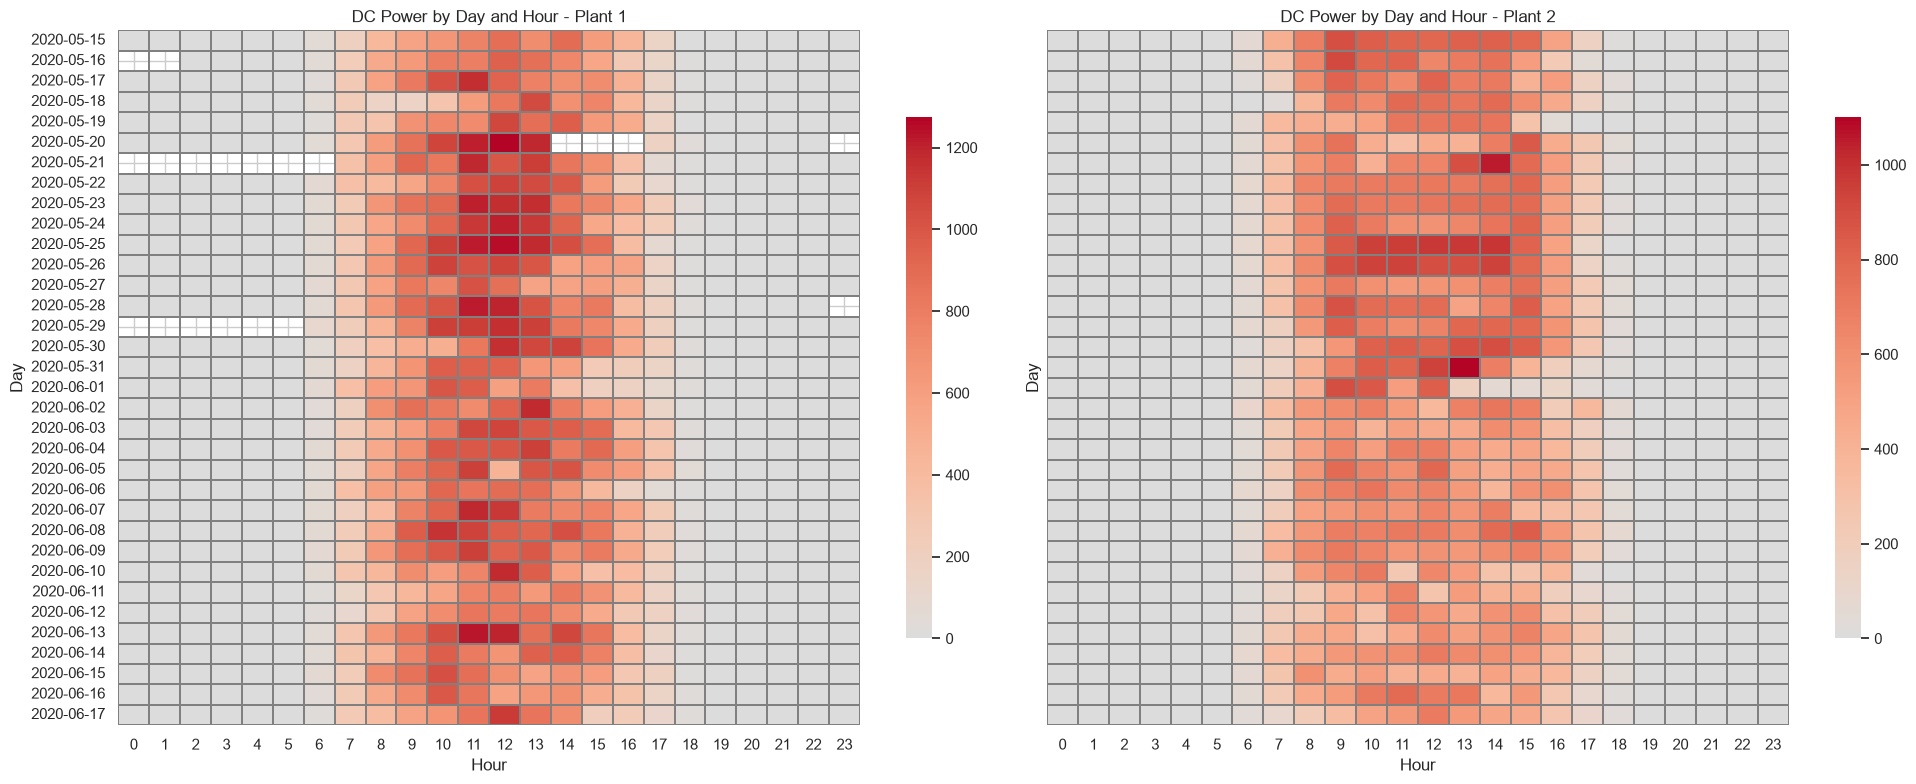

In [76]:
#Heatmaps de Potencia DC diaria por hora para las plantas 1 y 2

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

plants = {
    "Plant 1": "p1",
    "Plant 2": "p2",
}

for ax, (title, planta) in zip(axes, plants.items()):
    data_heatmap = (
        df_diario_potencia_dc[df_diario_potencia_dc["id_planta"] == planta]
        .pivot_table(
            index="fecha_dia",
            columns="hora",
            values="potencia_dc_kw"
        )
    )

    sns.heatmap(
        data_heatmap,
        ax=ax,
        cmap="coolwarm",
        center=0,
        annot=False,
        linewidths=0.2,
        linecolor="gray",
        cbar_kws={"shrink": 0.75},
        yticklabels=True
    )

    ax.set_title(f"DC Power by Day and Hour - {title}", fontsize=12)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Day")

plt.tight_layout()
plt.show()

- Los nulos en algunos tramos horarios nos indican que **no existen datos de potencia DC de todos los inversores en dichas horas**. Revisar dias concretos para encontrar fallos especificos por inverter.

#### Potencia DC VS Energia diaria en plantas 1 y 2

In [95]:
#Construir variable fecha a partir del indice en df
df["fecha"] = pd.to_datetime(df.index).normalize()

In [304]:
#Dataset temporal a nivel diario de potencia DC y energia con energia sumada
df_diario_potencia_energia = (df.groupby(['fecha','id_planta', 'id_inversor'])
.agg(potencia_dc_kw = ('potencia_dc_kw', 'sum'),
     energia_diaria_kwh = ('energia_diaria_kwh', 'max'))
.reset_index().sort_values(by=['id_planta', 'fecha'])
)
df_diario_potencia_energia_sumado = \
     df_diario_potencia_energia.groupby(['id_planta', 'fecha'])[['potencia_dc_kw', 'energia_diaria_kwh']].sum().reset_index()

In [305]:
#Ratio de Energia/Potencia diario
df_diario_potencia_energia_sumado['ratio_energia_potencia'] = \
    df_diario_potencia_energia_sumado['energia_diaria_kwh'] / df_diario_potencia_energia_sumado['potencia_dc_kw']

In [306]:
ref_ratio_energia_potencia_p1 = \
    df_diario_potencia_energia_sumado[df_diario_potencia_energia_sumado['id_planta'] == 'p1']['ratio_energia_potencia'].median()

ref_ratio_energia_potencia_p2 = \
    df_diario_potencia_energia_sumado[df_diario_potencia_energia_sumado['id_planta'] == 'p2']['ratio_energia_potencia'].median()

print(f"p1: {ref_ratio_energia_potencia_p1}\np2: {ref_ratio_energia_potencia_p2}")

p1: 0.2444308750965138
p2: 0.264795086068094


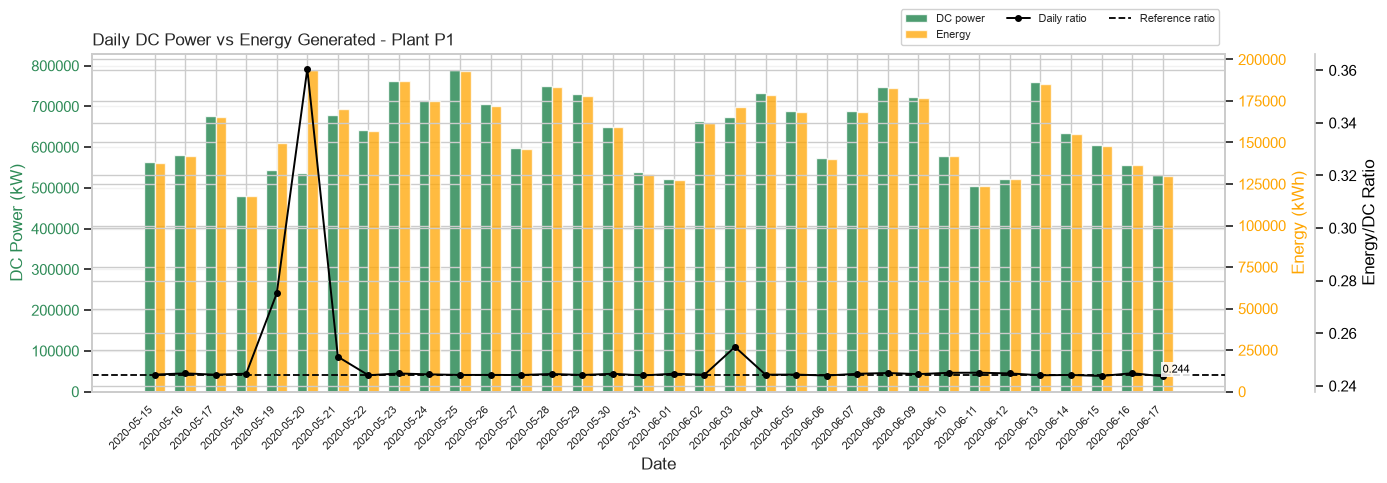

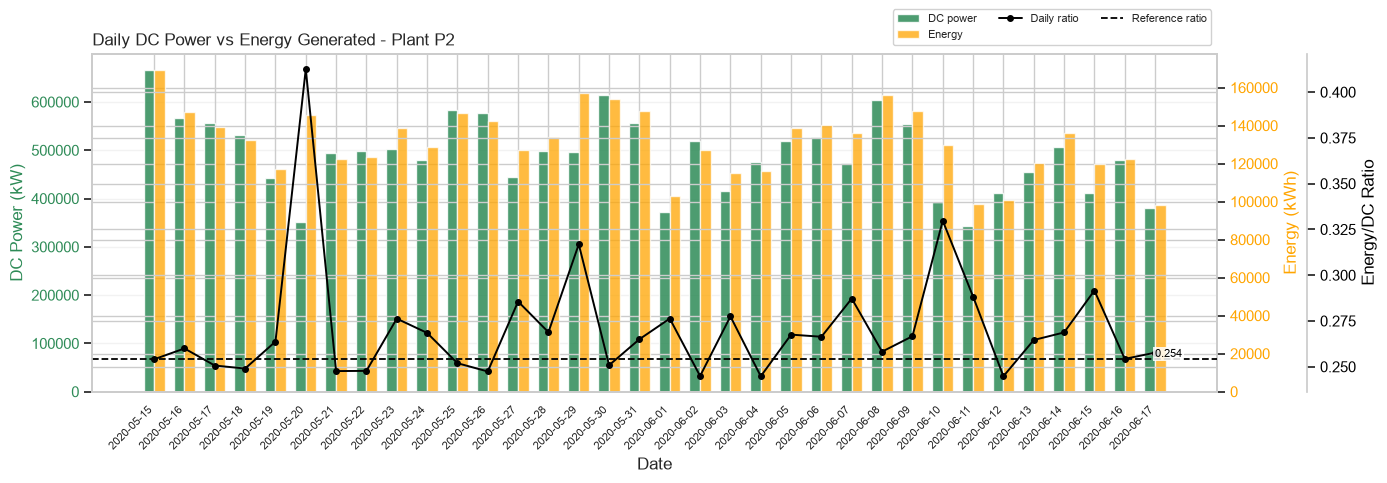

In [307]:
#Barplot diario de Energia vs Potencia DC con Ratio Energia-PotenciaDC por planta
for planta, d in df_diario_potencia_energia_sumado.groupby("id_planta"):
    d = d.sort_values("fecha").reset_index(drop=True)

    ref = (
        ref_ratio_energia_potencia[planta]
        if isinstance(ref_ratio_energia_potencia, dict)
        else ref_ratio_energia_potencia.loc[planta]
    )

    x = np.arange(len(d))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("axes", 1.08))

    b1 = ax1.bar(x - width / 2, d["potencia_dc_kw"], width, color="seagreen", alpha=0.85)
    b2 = ax2.bar(x + width / 2, d["energia_diaria_kwh"], width, color="orange", alpha=0.75)

    base = ax3.axhline(ref, color="black", linestyle="--", linewidth=1.3)
    line, = ax3.plot(x, d["ratio_energia_potencia"], "o-", color="black", linewidth=1.4, markersize=4)

    ax3.text(len(d) - 1,ref, f"{ref:.3f}",
        color="black",
        fontsize=8,
        ha="left",
        va="bottom",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5)
    )

    ax1.set_title(f"Daily DC Power vs Energy Generated - Plant {planta.upper()}", loc="left")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("DC Power (kW)", color="seagreen")
    ax2.set_ylabel("Energy (kWh)", color="orange")
    ax3.set_ylabel("Energy/DC Ratio", color="black")

    ax1.tick_params(axis="y", labelcolor="seagreen")
    ax2.tick_params(axis="y", labelcolor="orange")
    ax3.tick_params(axis="y", labelcolor="black")

    ax1.set_xticks(x)
    ax1.set_xticklabels(pd.to_datetime(d["fecha"]).dt.strftime("%Y-%m-%d"), rotation=45, ha="right", fontsize=8)

    ax1.legend([b1, b2, line, base],["DC power", "Energy", "Daily ratio", "Reference ratio"],
        loc="lower right",
        bbox_to_anchor=(1, 1.01),
        ncol=3,
        fontsize=8,
        framealpha=0.9
    )

    ax1.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

#### Análisis de anomalías en Potencia DC registrada por inverter en planta 1 y 2 en días concretos

In [295]:
#Filtros de días más anómalos
filter_p1 = (df['id_planta'] == 'p1') & (df['fecha'].isin(pd.to_datetime(['2020-05-19', '2020-05-20'])))
filter_p2 = (df['id_planta'] == 'p2') & (df['fecha'].isin(pd.to_datetime(['2020-05-20', '2020-05-27','2020-05-29','2020-06-10', '2020-06-11', '2020-06-15'])))

In [296]:
#Datasets temporales potencia DC por dia, hora y inverter
df_anomalias_inverters_p1 = df[filter_p1].groupby(['fecha', 'hora', 'id_inversor'])[['potencia_dc_kw']].mean().reset_index()
df_anomalias_inverters_p2 = df[filter_p2].groupby(['fecha', 'hora', 'id_inversor'])[['potencia_dc_kw']].mean().reset_index()

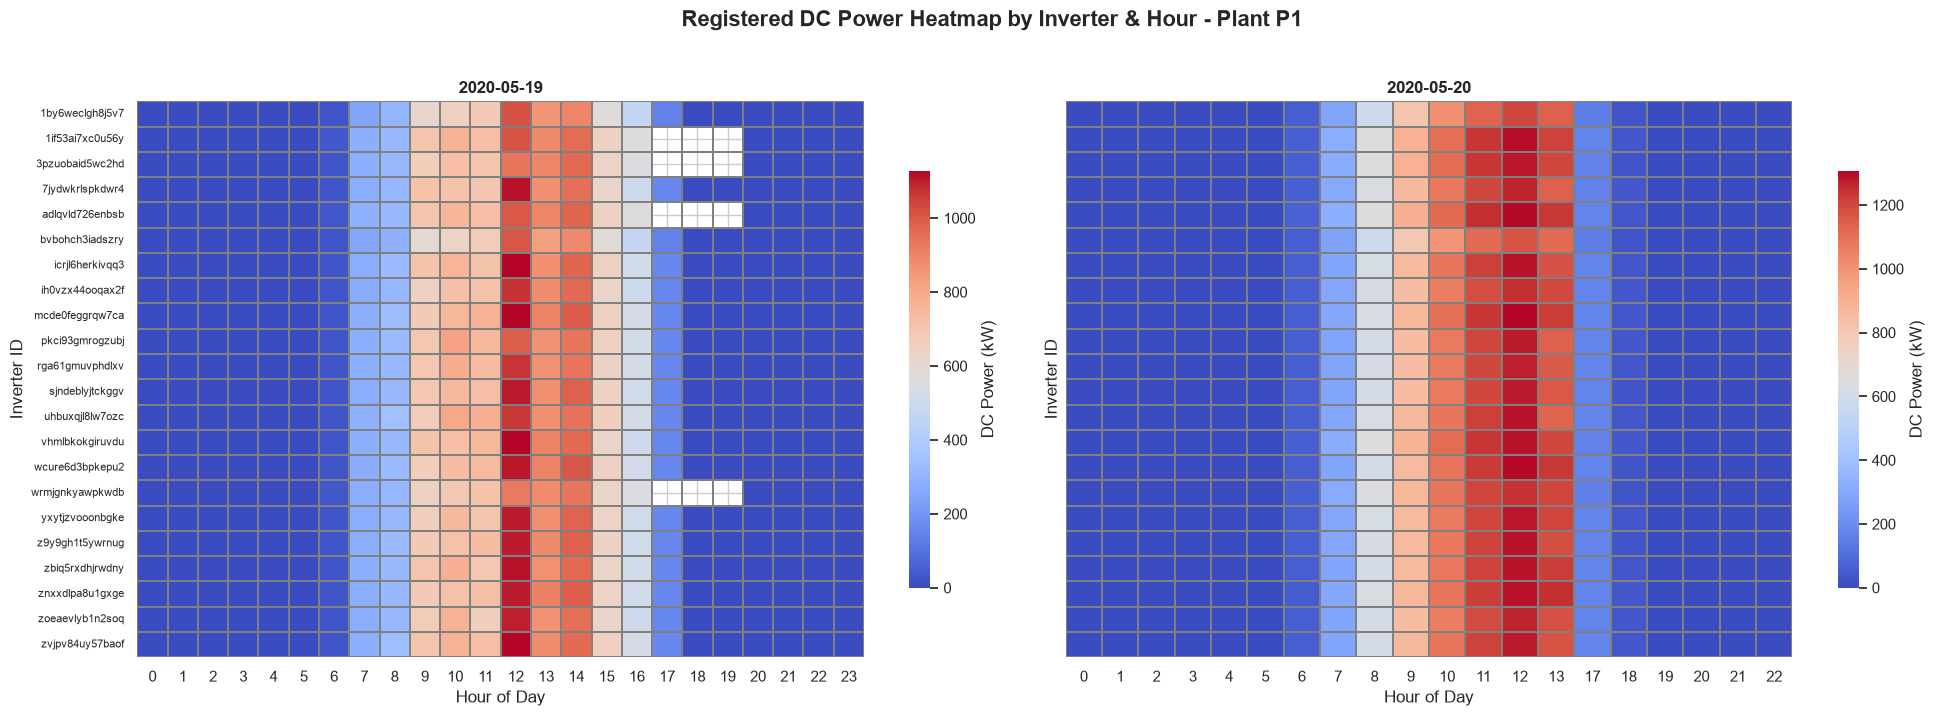

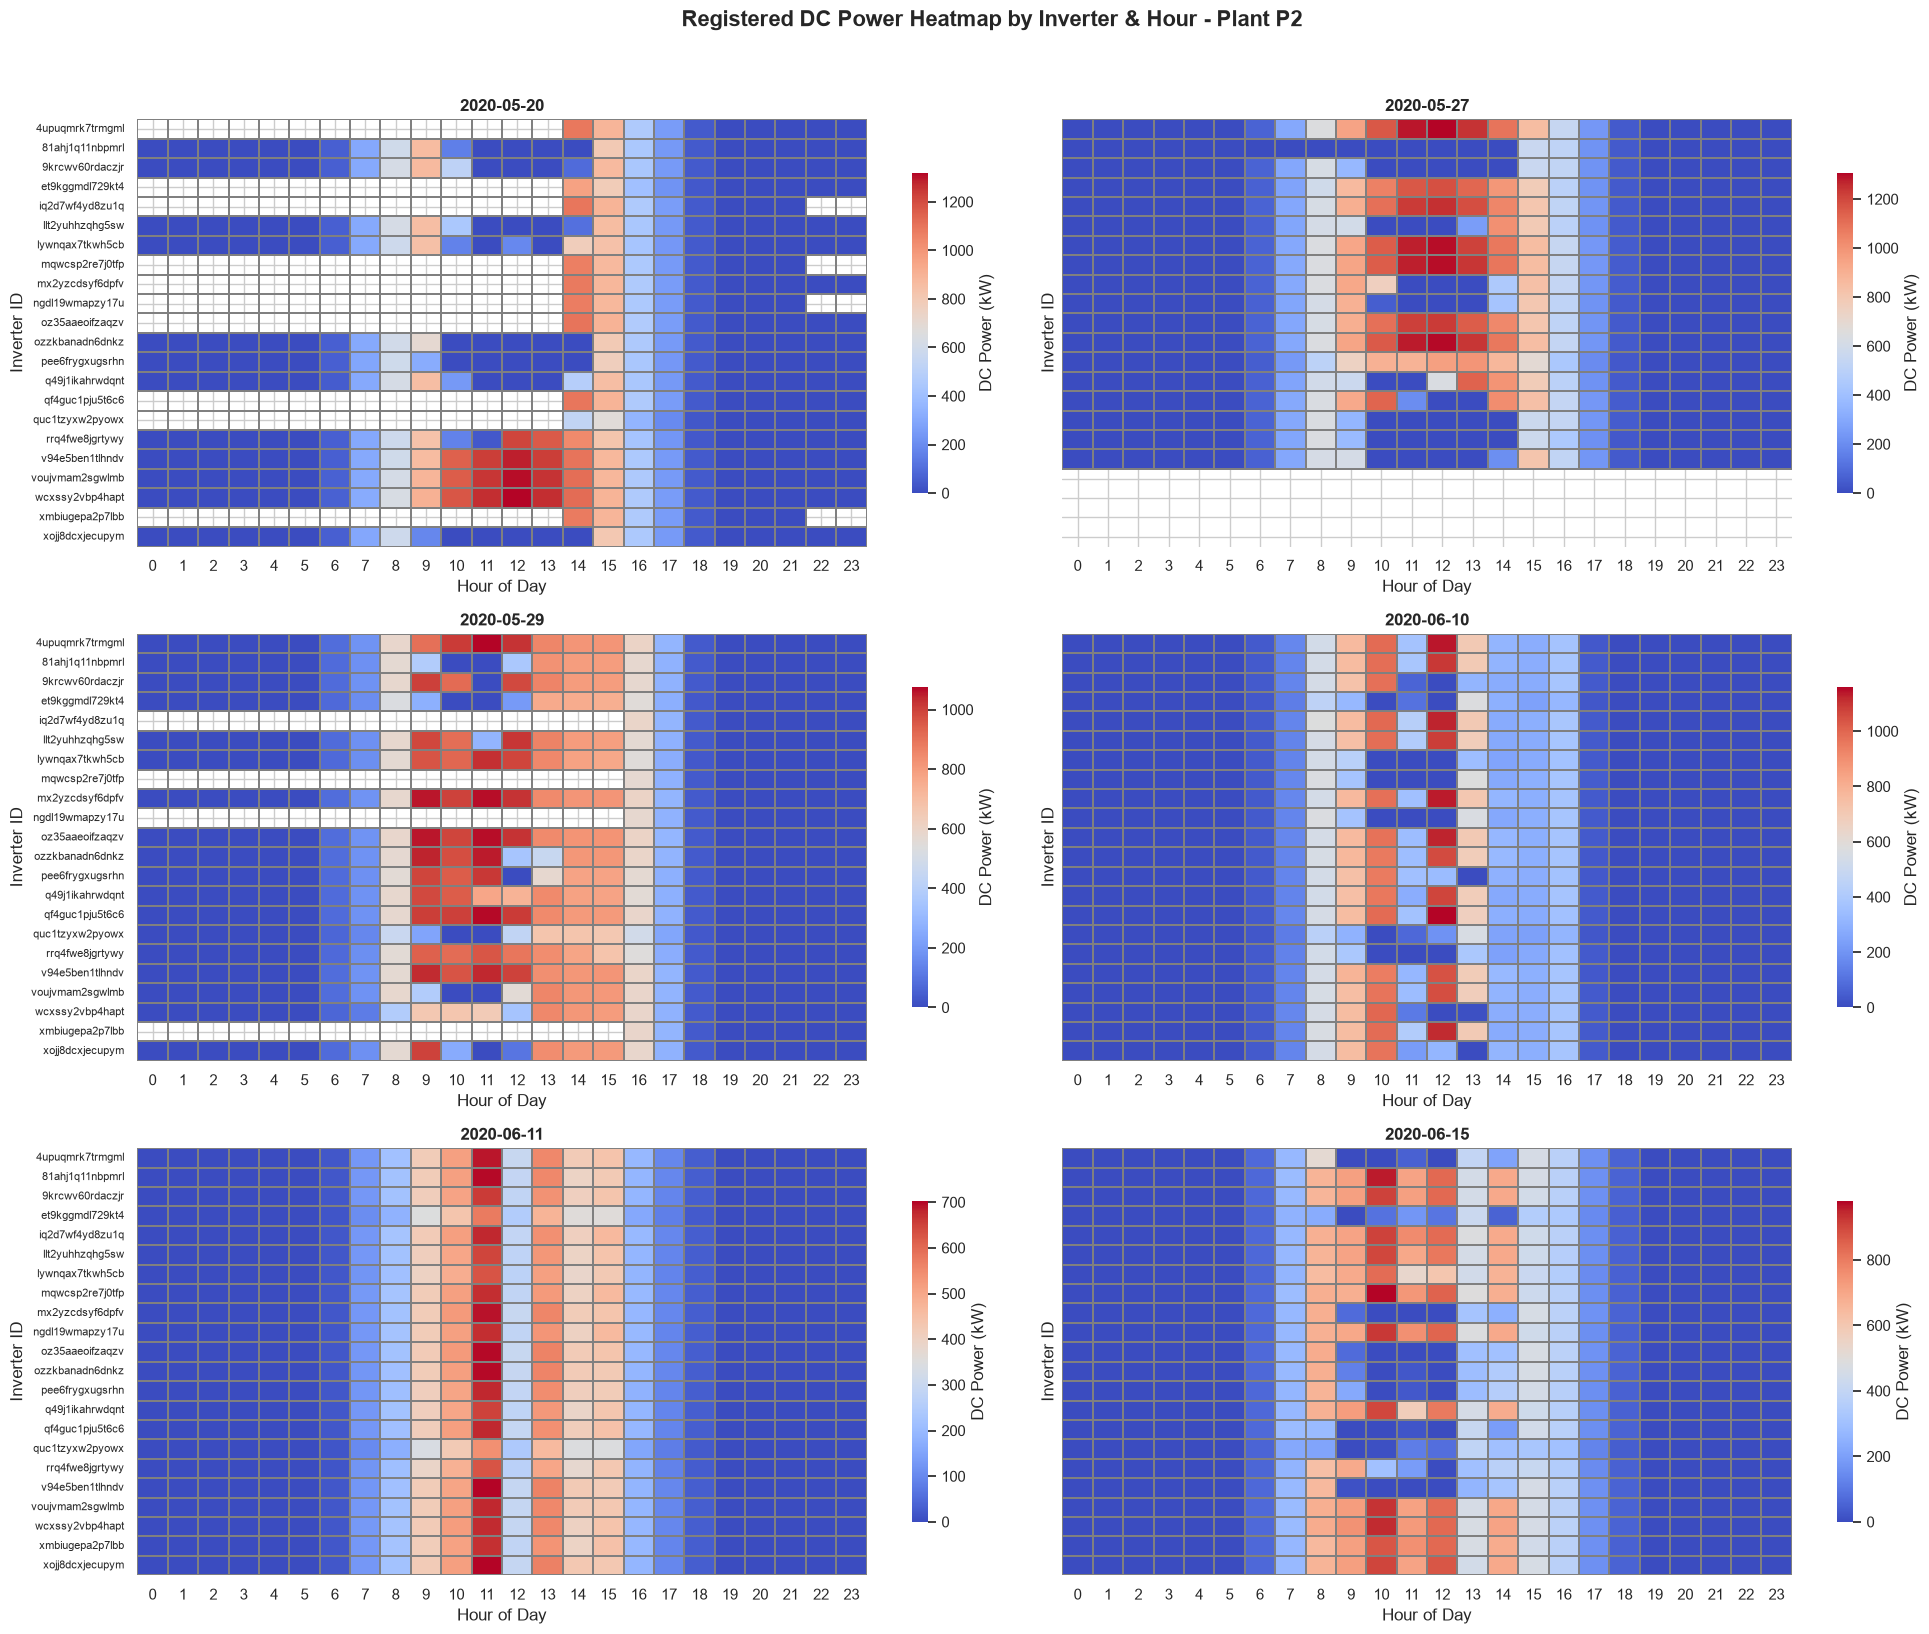

In [ ]:
#Heatmaps de Potencia DC por dia, hora, inverter y planta
plot_config = {
    "p1": {
        "df": df_anomalias_inverters_p1,
        "nrows": 1,
        "ncols": 2,
        "figsize": (20, 7),
    },
    "p2": {
        "df": df_anomalias_inverters_p2,
        "nrows": 3,
        "ncols": 2,
        "figsize": (20, 16),
    },
}

for planta, config in plot_config.items():
    df_anomalias = config["df"]
    dias_unicos = sorted(df_anomalias["fecha"].unique())

    fig, axes = plt.subplots(config["nrows"], config["ncols"],
        figsize=config["figsize"],
        sharex=False,
        sharey=True
    )

    axes = axes.flatten()

    for ax, dia in zip(axes, dias_unicos):
        df_dia = df_anomalias[df_anomalias["fecha"] == dia]

        pivot_data = df_dia.pivot_table(
            index="id_inversor",
            columns="hora",
            values="potencia_dc_kw",
            aggfunc="mean"
        )

        sns.heatmap(pivot_data,
            ax=ax,
            cmap="coolwarm",
            annot=False,
            cbar_kws={"label": "DC Power (kW)", "shrink": 0.75},
            linewidths=0.3,
            linecolor="gray"
        )

        ax.set_title(
            f"{pd.Timestamp(dia).strftime('%Y-%m-%d')}",
            fontsize=12,
            fontweight="bold"
        )
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel("Inverter ID")
        ax.tick_params(axis="x", rotation=0)
        ax.tick_params(axis="y", rotation=0, labelsize=8)

    for ax in axes[len(dias_unicos):]:
        ax.axis("off")

    fig.suptitle(
        f"Registered DC Power Heatmap by Inverter & Hour - Plant {planta.upper()}",
        fontsize=16,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

#### Insight 7: Fallos de medición de potencia DC/AC en los inversores
Algunos dias presentan niveles de potencia DC descorrelacionada con la energia generada. Esto indica que **existen fallos en la medición de dicha potencia por parte de los inversores**, aunque no se descartan desconexiones/paradas puntuales.

1. Planta 1: fallos de medición en 4 inversores concretos el dia 19 de Mayo y fallo de medición de todos los inversores de 14h a 16h el dia 20 de Mayo. Para el caso especifico del 20 de Mayo, debido a que la energia generada esta en valores estándares se confirma que muy probablemente sea un error de medición generalizado en bloque de todos los inversores.
2. Planta 2: multiples fallos de medición en distintos dias. Se observan fallos bastante distintos tanto por rango de horas como por cantidad de inversores fallando simultaneamente.

#### Analisis profundo de anomalías por Inversor y Planta

- Ausencia de registros de medición en los inversores.

In [180]:
# Horario solar
HORA_INI, HORA_FIN = 6, 20

df_solar = df[(df['hora'] >= HORA_INI) & (df['hora'] <= HORA_FIN)]

# Registros por inverter y día
registros_inv = df_solar.groupby(['fecha', 'id_planta', 'id_inversor'])['potencia_dc_kw'].count().reset_index()
registros_inv.columns = ['fecha', 'id_planta', 'id_inversor', 'n_registros']

# Mediana de registros por día y planta (baseline)
baseline = registros_inv.groupby(['fecha', 'id_planta'])['n_registros'].median().reset_index()
baseline.columns = ['fecha', 'id_planta', 'mediana_registros']

registros_inv = registros_inv.merge(baseline, on=['fecha', 'id_planta'])
registros_inv['pct_registros'] = registros_inv['n_registros'] / registros_inv['mediana_registros']
registros_inv['fallo_ausencia'] = registros_inv['pct_registros'] < 0.5

ausencias = registros_inv[registros_inv['fallo_ausencia']].sort_values(['id_planta', 'fecha'])
print(ausencias[['fecha', 'id_planta', 'id_inversor', 'n_registros', 'mediana_registros', 'pct_registros']])

         fecha id_planta      id_inversor  n_registros  mediana_registros  \
242 2020-05-20        p2  4UPUqMRk7TRMgml           27               60.0   
245 2020-05-20        p2  Et9kgGMDl729KT4           27               60.0   
246 2020-05-20        p2  IQ2d7wF4YD8zU1Q           27               60.0   
249 2020-05-20        p2  Mx2yZCDsyf6DPfv           27               60.0   
250 2020-05-20        p2  NgDl19wMapZy17u           27               60.0   
252 2020-05-20        p2  Qf4GUc1pJu5T6c6           27               60.0   
253 2020-05-20        p2  Quc1TzYxW2pYoWX           27               60.0   
256 2020-05-20        p2  mqwcsP2rE7J0TFp           27               60.0   
257 2020-05-20        p2  oZ35aAeoifZaQzV           27               60.0   
262 2020-05-20        p2  xMbIugepa2P7lBB           27               60.0   
610 2020-05-29        p2  IQ2d7wF4YD8zU1Q           19               59.0   
614 2020-05-29        p2  NgDl19wMapZy17u           19               59.0   

- Valores anómalos de medición en los inversores.

In [181]:
# Mediana horaria por día y planta
df_solar2 = df[(df['hora'] >= HORA_INI) & (df['hora'] <= HORA_FIN)].copy()

mediana_horaria = df_solar2.groupby(['fecha', 'id_planta', 'hora'])['potencia_dc_kw'].median().reset_index()
mediana_horaria.columns = ['fecha', 'id_planta', 'hora', 'mediana_potencia']

df_solar2 = df_solar2.merge(mediana_horaria, on=['fecha', 'id_planta', 'hora'])

# Anomalía: inverter con potencia < 5% de mediana, mientras mediana > 100kW
df_solar2['anomalia'] = (
    (df_solar2['potencia_dc_kw'] < df_solar2['mediana_potencia'] * 0.05) &
    (df_solar2['mediana_potencia'] > 100)
)

anomalias = df_solar2[df_solar2['anomalia']].groupby(
    ['id_planta', 'id_inversor']
).agg(
    n_horas_anomalas=('anomalia', 'sum'),
    dias_afectados=('fecha', 'nunique')
).reset_index().sort_values(['id_planta', 'n_horas_anomalas'], ascending=[True, False])

print(anomalias)

   id_planta      id_inversor  n_horas_anomalas  dias_afectados
2         p1  bvBOhCH3iADSZry                20               2
0         p1  1BY6WEcLGh8j5v7                19               2
6         p1  z9Y9gH1T5YWrNuG                 7               2
5         p1  wCURE6d3bPkepu2                 5               1
1         p1  McdE0feGgRqW7Ca                 3               1
4         p1  sjndEbLyjtCKgGv                 3               1
7         p1  zBIq5rxdHJRwDNY                 3               2
8         p1  zVJPv84UY57bAof                 2               1
3         p1  ih0vzX44oOqAx2f                 1               1
12        p2  Et9kgGMDl729KT4               294              28
14        p2  LYwnQax7tkwH5Cb               283              24
20        p2  Quc1TzYxW2pYoWX               272              27
27        p2  rrq4fwE8jgrTyWY               241              23
10        p2  81aHJ1q11NBPMrL               220              20
26        p2  q49J1IKaHRwDQnt           

- Ranking barplots finales: ausencias + anomalías.

In [192]:
# Combinar ausencias + anomalías
ranking_ausencias = ausencias.groupby(['id_planta', 'id_inversor']).agg(
    dias_ausencia=('fecha', 'nunique')
).reset_index()

ranking = anomalias.merge(ranking_ausencias, on=['id_planta', 'id_inversor'], how='outer').fillna(0)
ranking['score_total'] = ranking['n_horas_anomalas'] + ranking['dias_ausencia'] * 5  # peso mayor a ausencias
ranking = ranking.sort_values(['id_planta', 'score_total'], ascending=[True, False])

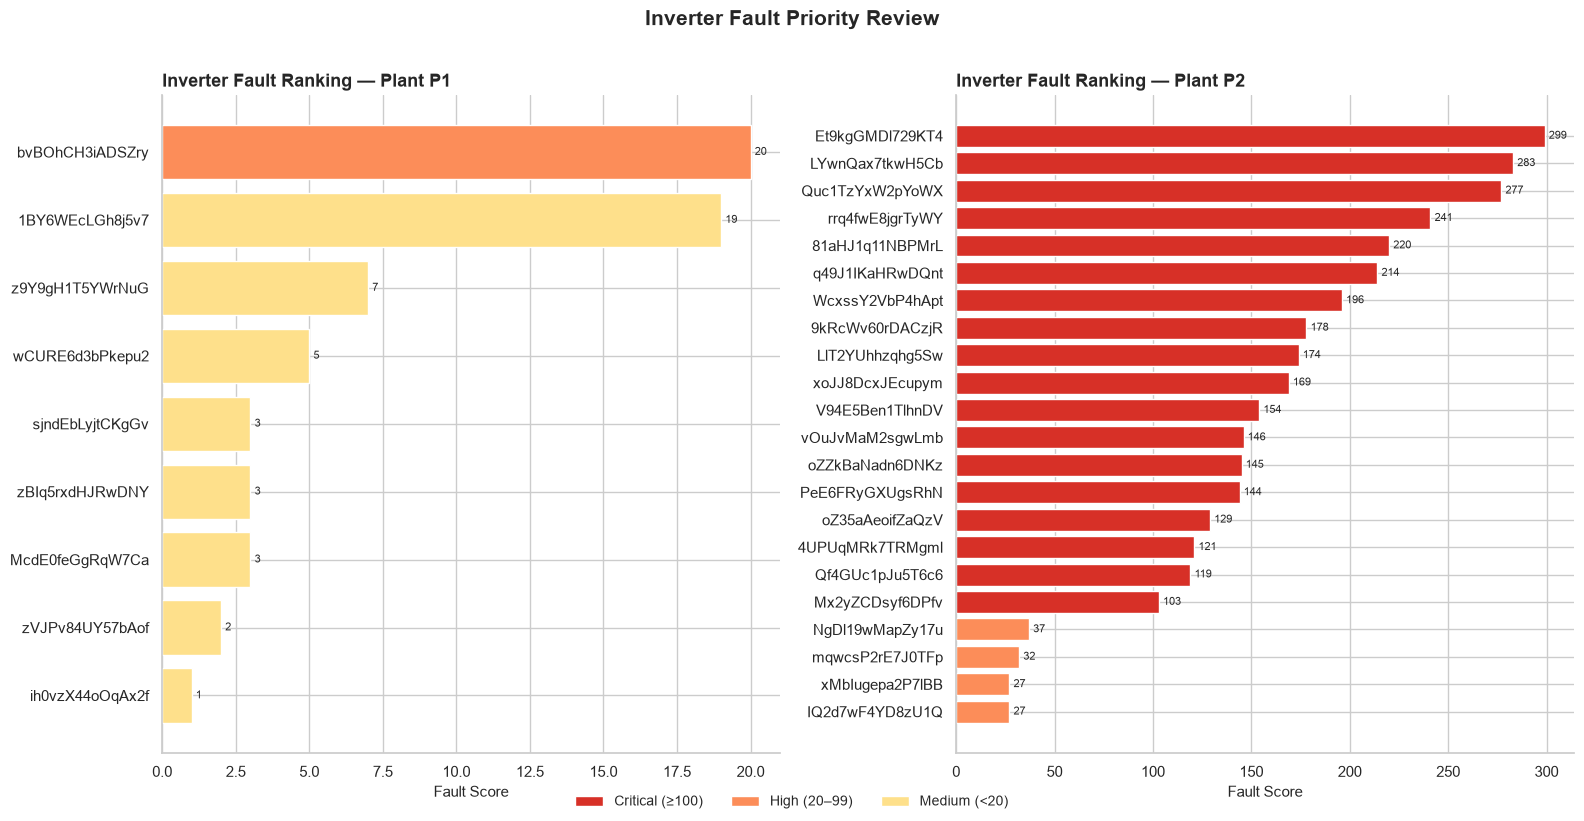

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, planta in zip(axes, ['p1', 'p2']):
    df_plot = ranking[ranking['id_planta'] == planta].sort_values('score_total')
    
    colors = ['#d73027' if s >= 100 else '#fc8d59' if s >= 20 else '#fee08b' 
              for s in df_plot['score_total']]
    
    bars = ax.barh(df_plot['id_inversor'], df_plot['score_total'], color=colors)
    ax.set_xlabel('Fault Score', fontsize=11)
    ax.set_title(f'Inverter Fault Ranking — Plant {planta.upper()}', fontsize=13, fontweight='bold', loc='left')
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

# Leyenda manual
legend_elements = [
    Patch(facecolor='#d73027', label='Critical (≥100)'),
    Patch(facecolor='#fc8d59', label='High (20–99)'),
    Patch(facecolor='#fee08b', label='Medium (<20)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, frameon=False)

plt.suptitle('Inverter Fault Priority Review', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/graphics/inverter-fault-ranking.png', dpi=150, bbox_inches='tight')
plt.show()